# Лабораторна робота №1: побудова та дослідження регресійних моделей

**Варіант:** 7 — Bike Sharing Dataset  
**Ціль:** `cnt` — погодинна кількість оренд.

Послідовність експерименту: задача → дані → baseline → кандидатні моделі → 5-fold часова валідація → вибір → незалежний test → аналіз похибок.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.bike_workflow import (
    chronological_split,
    load_bike_data,
    make_models,
    make_polynomial_preprocessor,
    make_preprocessor,
    split_features_target,
)

FIGURES = Path.cwd().parent / "figures"
FIGURES.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## 1. Постановка задачі та план

За календарними й погодними характеристиками потрібно передбачити кількість оренд протягом години. Прогноз корисний для агрегованого планування запасу велосипедів і ресурсів.

Останні 20% спостережень відкладаються як тестовий період. На перших 80% виконується `TimeSeriesSplit` із п’ятьма fold. Основна метрика — RMSE, оскільки великі помилки в плануванні особливо небажані; MAE додає робастну середню інтерпретацію, а R² показує виграш відносно середнього. Тест не використовується до остаточного вибору.

In [2]:
df = load_bike_data()
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = chronological_split(X, y)
cv = TimeSeriesSplit(n_splits=5)

print(f"Train: {len(X_train):,}; test: {len(X_test):,}")
print(f"Train до {df.loc[X_train.index, 'dteday'].max().date()}; test від {df.loc[X_test.index, 'dteday'].min().date()}")
print(f"Витокові поля відсутні: {set(['casual', 'registered']).isdisjoint(X.columns)}")

Train: 13,903; test: 3,476
Train до 2012-08-07; test від 2012-08-07
Витокові поля відсутні: True


## 2. Підбір параметрів усередині навчальної вибірки

In [3]:
ridge_rows = []
for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:
    model = Pipeline([
        ("preprocessor", make_polynomial_preprocessor()),
        ("model", Ridge(alpha=alpha)),
    ])
    scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    ridge_rows.append({"alpha": alpha, "CV RMSE": scores.mean(), "CV std": scores.std()})
ridge_tuning = pd.DataFrame(ridge_rows)
display(ridge_tuning.style.format({"CV RMSE": "{:.3f}", "CV std": "{:.3f}"}))
print(f"Обрано alpha={ridge_tuning.loc[ridge_tuning['CV RMSE'].idxmin(), 'alpha']:g}")

,alpha,CV RMSE,CV std
0,0.100000,108.805,21.605
1,1.000000,108.791,21.774
2,10.000000,109.582,22.249
3,100.000000,116.973,23.547
4,1000.000000,137.704,25.718


Обрано alpha=1


In [4]:
hgb_rows = []
for leaves in [15, 31, 63]:
    model = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=leaves,
            l2_regularization=1.0,
            random_state=42,
        )),
    ])
    scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    hgb_rows.append({"max_leaf_nodes": leaves, "CV RMSE": scores.mean(), "CV std": scores.std()})
hgb_tuning = pd.DataFrame(hgb_rows)
display(hgb_tuning.style.format({"CV RMSE": "{:.3f}", "CV std": "{:.3f}"}))
print(f"Обрано max_leaf_nodes={int(hgb_tuning.loc[hgb_tuning['CV RMSE'].idxmin(), 'max_leaf_nodes'])}")

,max_leaf_nodes,CV RMSE,CV std
0,15,77.343,17.372
1,31,82.579,22.895
2,63,85.029,21.421


Обрано max_leaf_nodes=15


Ridge має найкращий середній CV RMSE при `alpha=1`. Для HistGradientBoosting найкращим є обмеження 15 листків; більші дерева погіршують середній результат і стабільність.

## 3. Порівняння baseline та кандидатних моделей

In [5]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
models = make_models()
rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({
        "Модель": name,
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV std": (-scores["test_rmse"]).std(),
        "CV MAE": -scores["test_mae"].mean(),
        "CV R²": scores["test_r2"].mean(),
    })
cv_results = pd.DataFrame(rows).sort_values("CV RMSE").reset_index(drop=True)
display(cv_results.style.format({column: "{:.3f}" for column in cv_results.columns if column != "Модель"}))
cv_results.to_csv(Path.cwd().parent / "model_results.csv", index=False)

,Модель,CV RMSE,CV std,CV MAE,CV R²
0,HistGradientBoosting,77.343,17.372,55.583,0.752
1,Linear Regression,108.762,19.356,80.494,0.545
2,Polynomial d=2 (Ridge alpha=1),108.791,21.774,84.043,0.552
3,Baseline,180.481,42.717,138.079,-0.212


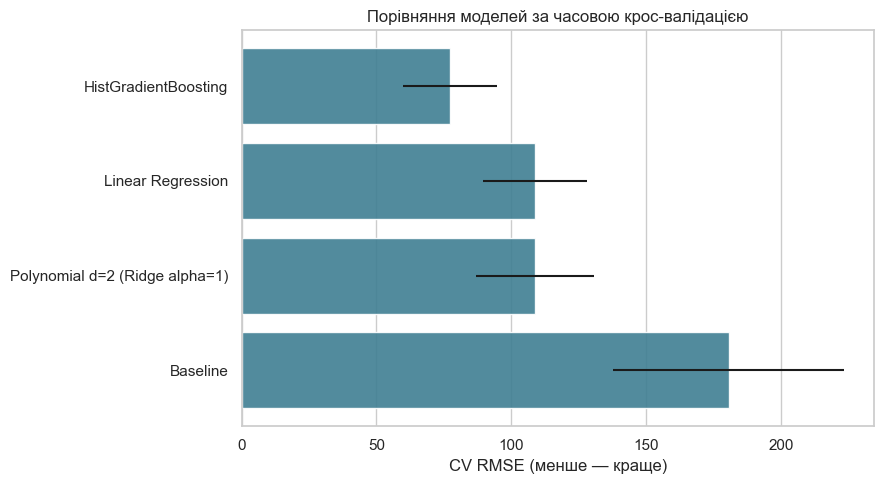

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = cv_results.sort_values("CV RMSE", ascending=False)
ax.barh(plot_data["Модель"], plot_data["CV RMSE"], xerr=plot_data["CV std"], color="#3f7f93", alpha=0.9)
ax.set(title="Порівняння моделей за часовою крос-валідацією", xlabel="CV RMSE (менше — краще)", ylabel="")
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

HistGradientBoosting має найменший середній CV RMSE (77,343) і менший розкид (17,372), ніж інші моделі. Усі ML-моделі перевищують baseline. Поліноміальний Ridge майже не покращує лінійну регресію, тому саме збільшення формальної складності не є достатньою підставою для вибору.

## 4. Незалежне тестування фінальної моделі

In [7]:
final_name = cv_results.iloc[0]["Модель"]
final_model = models[final_name].fit(X_train, y_train)
baseline_model = models["Baseline"].fit(X_train, y_train)

prediction = final_model.predict(X_test)
baseline_prediction = baseline_model.predict(X_test)

test_metrics = pd.DataFrame([
    {
        "Модель": "Baseline",
        "MAE": mean_absolute_error(y_test, baseline_prediction),
        "RMSE": mean_squared_error(y_test, baseline_prediction) ** 0.5,
        "R²": r2_score(y_test, baseline_prediction),
    },
    {
        "Модель": final_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "R²": r2_score(y_test, prediction),
    },
])
display(test_metrics.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R²": "{:.3f}"}))

,Модель,MAE,RMSE,R²
0,Baseline,174.985,232.608,-0.113
1,HistGradientBoosting,55.887,79.773,0.869


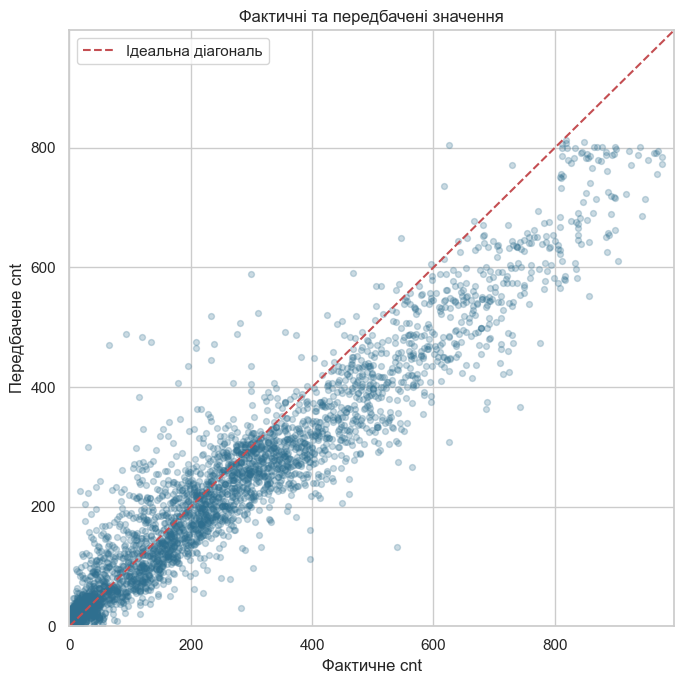

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, prediction, alpha=0.25, s=18, color="#2f6f8f")
limits = [0, max(y_test.max(), prediction.max()) * 1.02]
ax.plot(limits, limits, "--", color="#c44e52", label="Ідеальна діагональ")
ax.set(xlim=limits, ylim=limits, title="Фактичні та передбачені значення", xlabel="Фактичне cnt", ylabel="Передбачене cnt")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

Точки переважно розташовані біля діагоналі. На великих значеннях розкид зростає, а найвищі піки часто недооцінюються. На тесті модель отримала MAE 55,887, RMSE 79,773 і R² 0,869 проти RMSE 232,608 у baseline.

## 5. Аналіз залишків і найбільших похибок

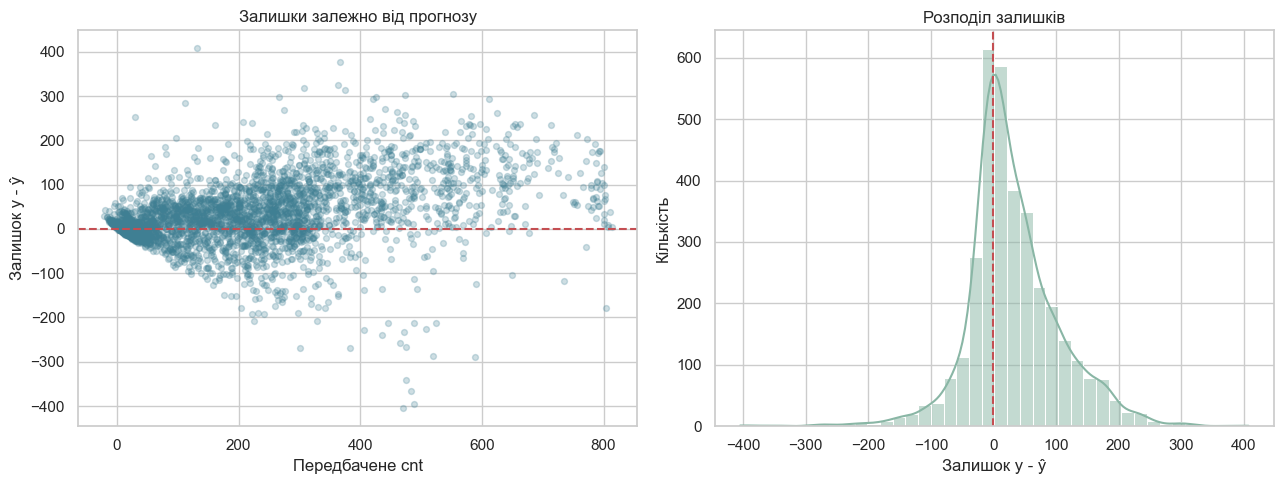

count    3476.000000
mean       31.620378
std        73.248746
min      -404.706318
25%        -9.227182
50%        19.392676
75%        67.202992
max       407.632973
dtype: float64


In [9]:
residual = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(prediction, residual, alpha=0.25, s=18, color="#3f7f93")
axes[0].axhline(0, color="#c44e52", linestyle="--")
axes[0].set(title="Залишки залежно від прогнозу", xlabel="Передбачене cnt", ylabel="Залишок y - ŷ")
sns.histplot(residual, bins=40, kde=True, ax=axes[1], color="#89b6a5")
axes[1].axvline(0, color="#c44e52", linestyle="--")
axes[1].set(title="Розподіл залишків", xlabel="Залишок y - ŷ", ylabel="Кількість")
fig.tight_layout()
fig.savefig(FIGURES / "residuals.png", dpi=160, bbox_inches="tight")
plt.show()

print(pd.Series(residual).describe())

,dteday,hr,weathersit,temp,hum,cnt,prediction,residual,absolute_error
16190,2012-11-12 00:00:00,8,1,0.420000,0.820000,540,132.37,407.63,407.63
17196,2012-12-24 00:00:00,8,1,0.220000,0.690000,66,470.71,-404.71,404.71
16454,2012-11-23 00:00:00,8,1,0.240000,0.870000,94,488.54,-394.54,394.54
15470,2012-10-11 00:00:00,19,1,0.440000,0.510000,743,366.94,376.06,376.06
13971,2012-08-10 00:00:00,8,3,0.620000,0.910000,119,484.30,-365.30,365.30
15243,2012-10-02 00:00:00,8,3,0.600000,0.880000,134,475.29,-341.29,341.29
15253,2012-10-02 00:00:00,18,3,0.620000,0.940000,687,362.72,324.28,324.28
14359,2012-08-26 00:00:00,12,3,0.720000,0.740000,626,308.37,317.63,317.63
15936,2012-11-01 00:00:00,17,3,0.400000,0.500000,689,374.53,314.47,314.47
15228,2012-10-01 00:00:00,17,3,0.560000,0.600000,856,552.16,303.84,303.84


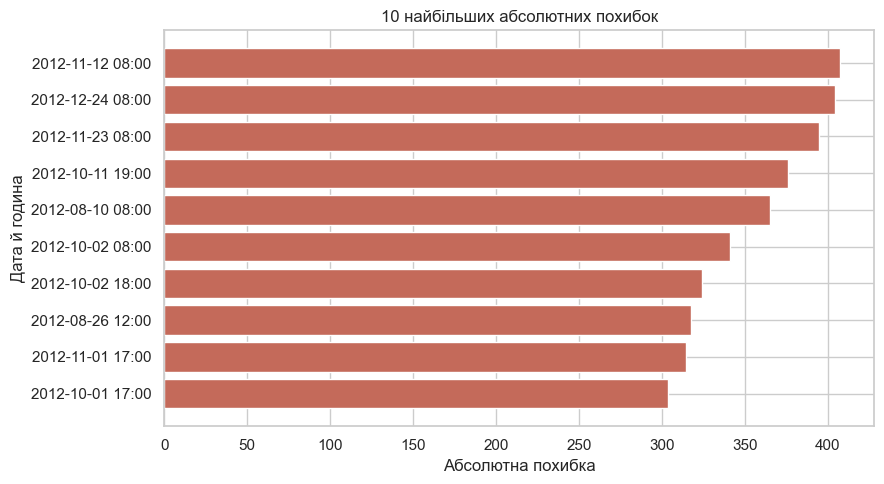

In [10]:
error_analysis = df.loc[X_test.index, ["dteday", "hr", "weathersit", "temp", "hum", "cnt"]].copy()
error_analysis["prediction"] = prediction
error_analysis["residual"] = residual
error_analysis["absolute_error"] = np.abs(residual)
worst = error_analysis.nlargest(10, "absolute_error")
display(worst.style.format({"prediction": "{:.2f}", "residual": "{:.2f}", "absolute_error": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9, 5))
top10 = worst.sort_values("absolute_error")
labels = top10["dteday"].dt.strftime("%Y-%m-%d") + " " + top10["hr"].astype(str).str.zfill(2) + ":00"
ax.barh(labels, top10["absolute_error"], color="#c46a5a")
ax.set(title="10 найбільших абсолютних похибок", xlabel="Абсолютна похибка", ylabel="Дата й година")
fig.tight_layout()
fig.savefig(FIGURES / "worst_errors.png", dpi=160, bbox_inches="tight")
plt.show()

Великі похибки концентруються в пікові години. Святвечір і день після Thanksgiving не позначені набором як офіційні свята, тому календарні ознаки підказують моделі типовий робочий патерн, якого фактично немає. Інші помилки пов’язані з сильною негодою або нетипово високим попитом. Це вказує на відсутність ознак спеціальних подій і локального контексту.

## 6. Обґрунтування фінальної моделі

HistGradientBoosting вибрано до перегляду тесту за сукупністю факторів: найкращий CV RMSE, найнижчий розкид між fold серед кандидатів, значна перевага над baseline та здатність моделювати нелінійні ефекти й взаємодії. Модель менш інтерпретована за лінійну, але її виграш достатньо великий для прикладної задачі агрегованого прогнозування.

## 7. Висновки

1. Тестовий RMSE зменшено з 232,608 у baseline до 79,773.
2. Найкраща за CV — HistGradientBoosting із `max_leaf_nodes=15`.
3. Поліноміальне розширення не дало переконливого CV-виграшу над лінійною регресією.
4. Фінальні метрики: MAE 55,887, RMSE 79,773, R² 0,869.
5. Типові помилки помірні, але є великі недооцінки й переоцінки піків.
6. Найгірші об’єкти пов’язані зі святковими винятками, негодою та нетиповими піками.
7. Обмеження: лише 2011–2012 роки, відсутність подій і станційних даних, рідкісна найгірша погода.
8. Модель придатна для агрегованого погодинного планування, але не для точного керування станціями.
9. Подальші кроки: лагові й циклічні часові ознаки, календар подій, довший період та ширший пошук параметрів.